# Standard pipeline: analyzing 5K PBMC dataset from 10X genomics


## Introduction <a name="introduction"></a>

In this tutorial we will analyze single-cell ATAC-seq data from Peripheral blood mononuclear cells (PBMCs).

## Import library and environment setup <a name="setup"></a>

In [1]:
import snapatac2 as snap

The fragment file can be download from 10X genomics [website](https://cf.10xgenomics.com/samples/cell-atac/2.0.0/atac_pbmc_5k_nextgem/atac_pbmc_5k_nextgem_fragments.tsv.gz). We also need a gene annotation file which can be downloaded from [Gencode](https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_39/gencode.v39.basic.annotation.gff3.gz).

In [2]:
# Input files
fragment_file = "data/atac_pbmc_5k_nextgem_fragments.tsv.gz"
gene_annotation = "data/gencode.v39.basic.annotation.gff3.gz"

## Preprocessing <a name="preprocessing"></a>

We start off on data preprocessing by importing the fragment files and computing QC metric, which is achieved by calling the funciton `import_data`.

This function generates genome-wide TN5 insertion counts and stored the result in an anndata file (default to "data.h5ad") (Click [here](https://anndata.readthedocs.io/en/latest/) to learn more about the `anndata` format). During this process, various quality controls, such as TSS enrichment, the number of unique fragments per cell, will also be computed and stored in the anndata.

In [3]:
%%time
data = snap.pp.import_data(
    fragment_file,
    gene_annotation,
    snap.genome.hg38,
    file = "pbmc.h5ad",
    sorted_by_barcode=False,
)
data

CPU times: user 6min 8s, sys: 9.09 s, total: 6min 17s
Wall time: 6min 13s


AnnData object with n_obs x n_vars = 14227 x 0 backed at 'pbmc.h5ad'
    obs: Cell, tsse, n_fragment, frac_dup, frac_mito
    obsm: insertion
    uns: reference_sequences

To identify usable/high-quality cells, we can plot TSS enrichment against number of unique fragments for each cell.

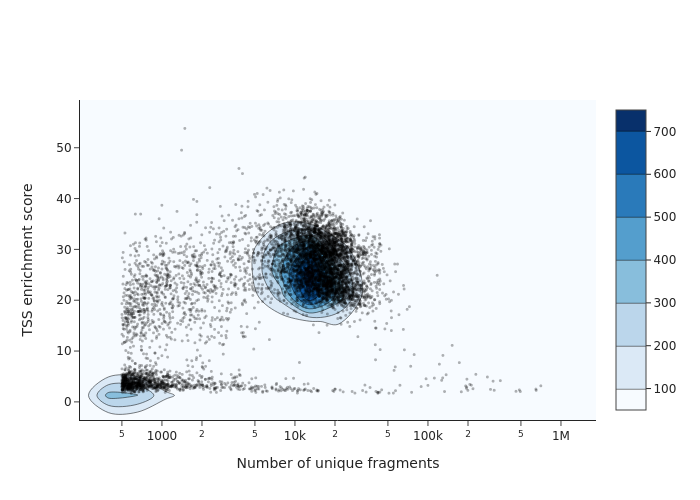

In [4]:
snap.pl.tsse(data, show_cells=True, interactive=False)

The cells on the upper right corresponds to valid/high-quality cells, while the cells on the lower left corresponds to low-quality cells or empty dropblets. According to this plot, we decided to choose minimum TSS enrichment of 10 and minimum number of fragments of 5000 to filter the cells.

In [5]:
%%time
snap.pp.filter_cells(data, min_counts=5000, min_tsse=10, max_counts=50000)
data

CPU times: user 27.7 s, sys: 1.6 s, total: 29.3 s
Wall time: 28.9 s


AnnData object with n_obs x n_vars = 4544 x 0 backed at 'pbmc.h5ad'
    obs: Cell, tsse, n_fragment, frac_dup, frac_mito
    obsm: insertion
    uns: reference_sequences

We next create a cell by bin matrix containing insertion counts across genome-wide 500-bp bins.

In [6]:
%%time
snap.pp.make_tile_matrix(data)

CPU times: user 2min 38s, sys: 4.34 s, total: 2min 43s
Wall time: 1min 8s


We next perform feature selection to remove bins with low variability. The result is stored in `data.var["selected"]` and will be automatically picked up by relavent functions such as `snap.pp.scrublet` and `snap.tl.spectral`.

The default feature selection algorithm selects variable features. You can pass filter list to the function such as blacklist or whitelist. For example, `pp.select_features(data, blacklist="blacklist.bed")`.

In [7]:
# Feature selection
snap.pp.select_features(data)

### Doublet removal

Here we apply a customized scrublet algorithm to identify potential doublets. Calling `snap.pp.scrublet` will assign a doublet score to each cell. We can then use `snap.pp.call_doublets` to get the doublet score threshold to identify potential doublets. The result can be plotted by `snap.pl.scrublet`.

In [8]:
%%time
snap.pp.scrublet(data)

Simulating doublets...
Spectral embedding ...
Calculating doublet scores...
CPU times: user 2min 14s, sys: 34.7 s, total: 2min 49s
Wall time: 1min 13s


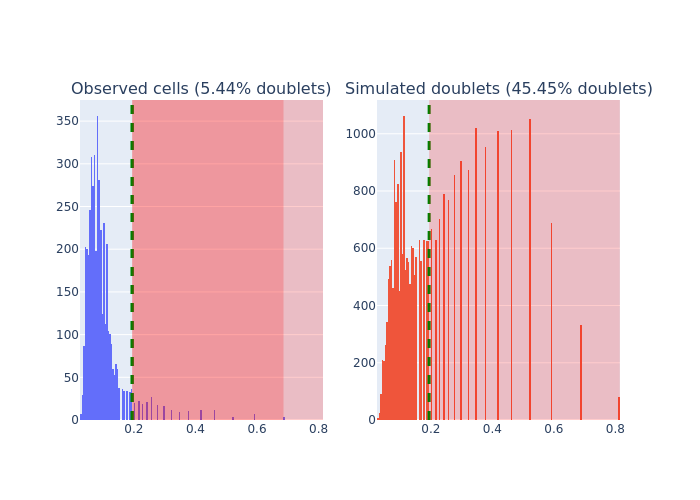

In [9]:
snap.pp.call_doublets(data)
snap.pl.scrublet(data, interactive=False)

This line does the actual filtering.

In [10]:
data.subset(data.obs["is_doublet"] == False)
data

AnnData object with n_obs x n_vars = 4297 x 6176550 backed at 'pbmc.h5ad'
    obs: Cell, tsse, n_fragment, frac_dup, frac_mito, doublet_score, is_doublet
    var: Feature_ID, selected
    obsm: insertion
    uns: scrublet_sim_doublet_score, scrublet_threshold, reference_sequences

## Dimenstion reduction <a name="dimension_reduction"></a>

To compute the lower dimensional representation of single-cell chromatin profiles, we first compute the pairwise read-depth normalized jaccard similarity. We then use the spectral embedding to perform the dimension reduction. All these steps were packed into a single function `snap.tl.spectral`. The result is stored in `data.obsm['X_spectral']`. Note we also provide alternative similarity metric such as the cosine similarity. Full details about the algorithm we used in dimension reduction can be found [here](../algorithms/dimension_reduction.rst).

In [11]:
%%time
snap.tl.spectral(data)

/home/kaizhang/data/software/miniconda3/lib/python3.8/site-packages/snapatac2/tools/_spectral.py:17: RuntimeWarning:

divide by zero encountered in true_divide



Compute similarity matrix
Normalization
Perform decomposition
CPU times: user 32.4 s, sys: 29.2 s, total: 1min 1s
Wall time: 14.7 s


We then plot the top eigenvalues corresponding to the first `n` eigenvectors/components. Using the elbow method, we pick the first 15 components in subsequent analysis. Note that selecting approporiate number of components is critical for getting best clustering accuracy.

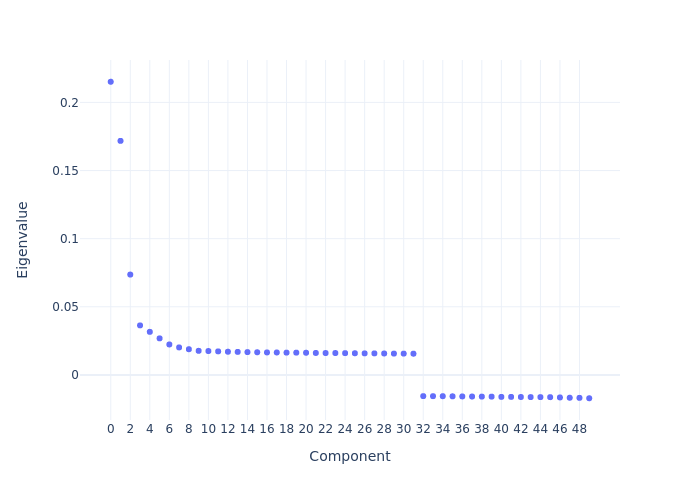

In [12]:
snap.pl.spectral_eigenvalues(data, interactive=False)

We then use UMAP to embed the cells to 2-dimension space for visualization purpose. This step will have to be run after `snap.tl.spectral` as it uses the lower dimesnional representation created by the spectral embedding.

In [13]:
%%time
snap.tl.umap(data, use_dims=10)

/home/kaizhang/data/software/miniconda3/lib/python3.8/site-packages/umap/__init__.py:9: UserWarning:

Tensorflow not installed; ParametricUMAP will be unavailable



CPU times: user 36.9 s, sys: 9.98 s, total: 46.9 s
Wall time: 34.7 s


## Clustering analysis <a name="clustering"></a>

We next perform graph-based clustering to identify cell clusters. We first build a k-nearest neighbour graph using `snap.pp.knn`, and then use the Leiden community detection algorithm to identify densely-connected subgraphs/clusters in the graph. The graph-based clustering algorithm usually outperform other methods. Here we also run the k-means algorithm as a comparison.

In [14]:
%%time
snap.pp.knn(data, use_dims=10)
snap.tl.leiden(data)

CPU times: user 2.46 s, sys: 80.4 ms, total: 2.54 s
Wall time: 718 ms


/home/kaizhang/data/software/miniconda3/lib/python3.8/site-packages/polars/internals/frame.py:1675: UserWarning:

setting a DataFrame by indexing is deprecated; Consider using DataFrame.with_column



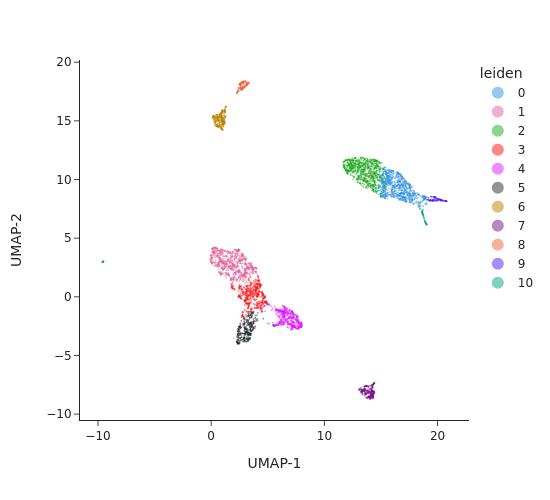

In [15]:
snap.pl.umap(data, color="leiden", interactive=False)

## Cell cluster annotation <a name="annotation"></a>

### Create the cell by gene activity matrix

Now that we have the cell clusters, we will try to annotate the clusters and assign them to known cell types. To do this, we will need to compute the gene activities first for each cell, and store the result in a cell by gene activity matrix. These steps can be done by calling the `snap.pp.make_gene_matrix` function, providing a appropriate gene annotation file.

In [16]:
%%time
gene_matrix = snap.pp.make_gene_matrix(data, gene_annotation, file = "gene_matrix.h5ad")
gene_matrix

CPU times: user 15min 58s, sys: 10.9 s, total: 16min 9s
Wall time: 1min 33s


AnnData object with n_obs x n_vars = 4297 x 60286 backed at 'gene_matrix.h5ad'
    obs: Cell, tsse, n_fragment, frac_dup, frac_mito, doublet_score, is_doublet, leiden
    var: Feature_ID

### Imputation

The cell by gene activity matrix is usually very sparse. To ease the visulization and marker gene identification, we use the MAGIC algorithm to perform imputation and data smoothing.

The subsequent steps are similar to those in single-cell RNA-seq analysis, we therefore leverage the [scanpy](https://scanpy.readthedocs.io/en/stable/) package to do this.

Let's close the files opened by snapatac2 and then open it in scanpy to continue our analysis.

In [17]:
import scanpy as sc
gene_matrix.close()
gene_matrix = sc.read("gene_matrix.h5ad")

We first perform gene filtering, data normalization, data transformation, and then call the `sc.external.pp.magic` function to complete the imputation.

In [18]:
sc.pp.filter_genes(gene_matrix, min_cells= 5)
sc.pp.normalize_total(gene_matrix)
sc.pp.log1p(gene_matrix)

In [20]:
%%time
sc.external.pp.magic(gene_matrix, solver="approximate")

/home/kaizhang/.local/lib/python3.8/site-packages/magic/utils.py:145: FutureWarning:

X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.



CPU times: user 1min 5s, sys: 36.5 s, total: 1min 41s
Wall time: 47.5 s


In [19]:
# Copy umap embedding
gene_matrix.obsm["X_umap"] = data.obsm["X_umap"]

We can then visualize the gene activity of a few marker genes.

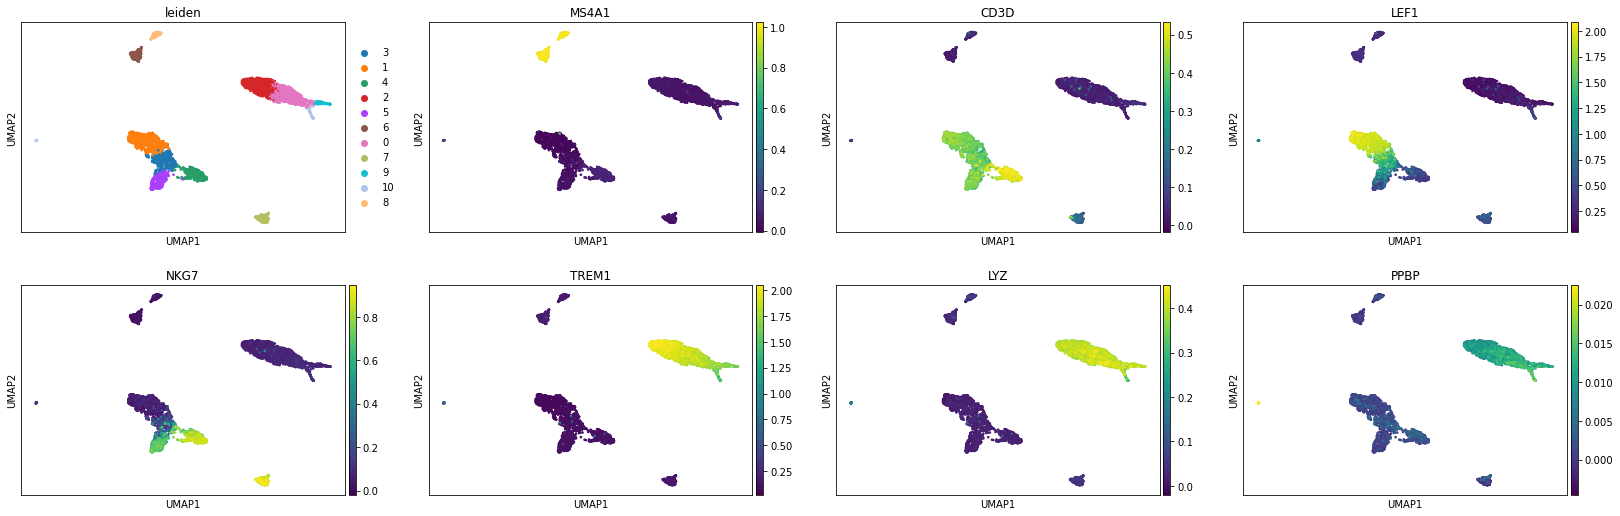

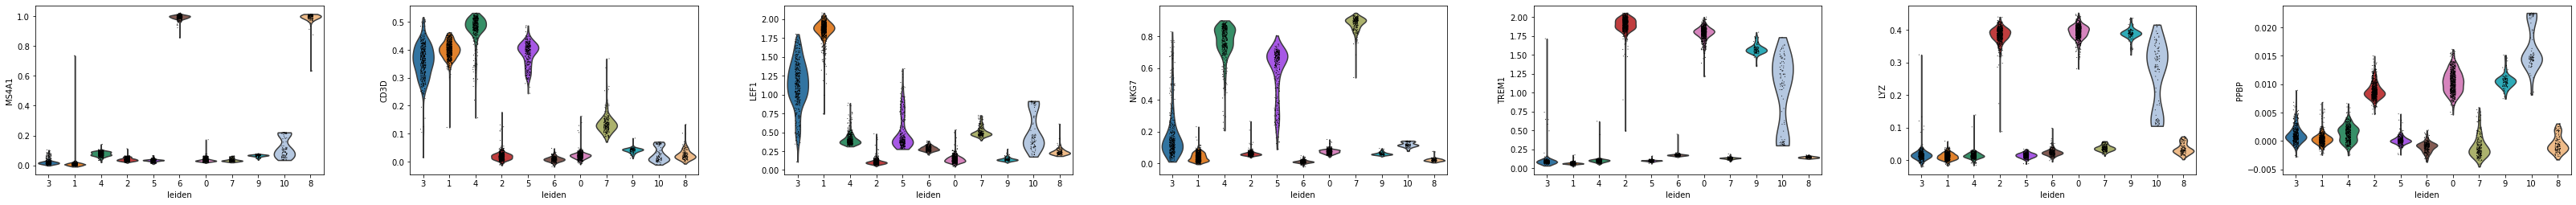

In [21]:
marker_genes = ['MS4A1', 'CD3D', 'LEF1', 'NKG7', 'TREM1', 'LYZ', 'PPBP']
sc.pl.umap(gene_matrix, use_raw=False, color=["leiden"] + marker_genes)
sc.pl.violin(gene_matrix, marker_genes, use_raw=False, groupby='leiden')

## Peak calling at the cluster-level

An important goal of single-cell ATAC-seq analysis is to identify genomic regions that are enriched with TN5 insertions, or "open chromatin" regions. Using `snap.tl.call_peaks`, we can easily identify open chromatin regions in different cell populations stratified by provided group information.

In [22]:
%%time
snap.tl.call_peaks(data, group_by = "leiden")

/home/kaizhang/data/software/miniconda3/lib/python3.8/site-packages/polars/internals/frame.py:1675: UserWarning:

setting a DataFrame by indexing is deprecated; Consider using DataFrame.with_column



CPU times: user 1min 5s, sys: 12.5 s, total: 1min 17s
Wall time: 3min 22s


preparing input...
calling peaks for 11 groups...
group 8: done!
group 9: done!
group 6: done!
group 7: done!
group 5: done!
group 10: done!
group 3: done!
group 4: done!
group 1: done!
group 2: done!
group 0: done!


`snap.tl.call_peaks` first calls peaks for individual groups and then merges overlapping peaks to create a list of fix-width non-overlapping peaks. The intermediate results are discarded by default but can be saved using the `out_dir` parameter.

Results of peak calling are stored in `data.uns['peaks']` as a dataframe. Rows are merged peaks, and columns are cell clusters. Boolean values in the dataframe indicate whether a peak is present in a given cell cluster.

In [23]:
data.uns['peaks']

Peaks,10,6,3,7,4,2,0,5,8,1,9
str,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool
"""chr1:180641-181142""",false,false,true,true,true,true,false,false,false,false,false
"""chr1:181213-181714""",false,false,false,false,false,false,false,false,false,true,false
"""chr1:191594-192095""",false,false,false,true,true,true,false,true,false,false,false
"""chr1:267750-268251""",true,false,true,false,true,true,true,false,false,false,false
"""chr1:585944-586445""",false,false,false,false,false,false,false,false,true,false,false
"""chr1:629690-630191""",false,true,false,false,false,false,false,false,true,true,false
"""chr1:633773-634274""",false,true,true,true,true,true,true,true,true,true,false
"""chr1:634467-634968""",false,false,false,false,false,false,false,false,true,false,false
"""chr1:778451-778952""",true,true,true,true,true,true,true,true,true,true,true


Now, with the peak list, we can create a cell by peak matrix by `snap.pp.make_peak_matrix`.

In [24]:
%%time
peak_mat = snap.pp.make_peak_matrix(data, file = "peak_matrix.h5ad")
peak_mat

CPU times: user 11min 24s, sys: 10.9 s, total: 11min 35s
Wall time: 1min 7s


AnnData object with n_obs x n_vars = 4297 x 246212 backed at 'peak_matrix.h5ad'
    obs: Cell, tsse, n_fragment, frac_dup, frac_mito, doublet_score, is_doublet, leiden
    var: Feature_ID

### Close AnnData objects

The AnnData objects in SnapATAC are always opened in backed mode and synchronized with the HDF5 files. By doing so, we use significantly less memory and much faster startup time. And you don't need to save your results during the analysis as the file is always up to date. As a result, it is important to close all AnnData objects before shutdown the Python process to avoid HDF5 file corruptions, using the command below:

In [25]:
data.close()
data

Closed AnnData object

Now it is safe to close and shutdown the notebook! Next time you can load the results using `data = snap.read("pbmc.h5ad")`.